<a href="https://colab.research.google.com/github/deepan98raj-dotcom/Assessment/blob/main/linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# linear Regression

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Load the dataset from csv file

data = pd.read_csv('/content/Salary_dataset.csv')


In [ ]:
col = ['Emma Smith','Liam Johnson','Olivia Williams','Noah Brown','Ava Jones','Ethan Garcia','Sophia Miller','Mason Davis','Isabella Rodriguez','Lucas Martinez',
       'Mia Hernandez','James Lopez','Harper Gonzalez','Benjamin Wilson','Evelyn Anderson','Logan Thomas','Abigail Taylor','Alexander Moore','Emily Jackson',
       'Ethan Martin','Elizabeth Lee','Daniel Perez','Sofia Thompson','Matthew White','Camila Harris','Henry Sanchez','Aria Clark','Jackson Ramirez',
       'Victoria Lewis','Sebastian Robinson']

# Assign the list to the 'Unnamed: 0' column if it exists
if 'Unnamed: 0' in data.columns:
    data['Unnamed: 0'] = col
    # Rename the column if it still exists after assignment
    data = data.rename(columns={'Unnamed: 0': 'Employee Name'})

# Display the updated DataFrame head to confirm the change
display(data.head())

,Employee Name,YearsExperience,Salary
0,Emma Smith,1.2,39344.0
1,Liam Johnson,1.4,46206.0
2,Olivia Williams,1.6,37732.0
3,Noah Brown,2.1,43526.0
4,Ava Jones,2.3,39892.0


In [ ]:
print(data.shape)
print(data.head())
data.info()

(30, 3)
     Employee Name  YearsExperience   Salary
0       Emma Smith              1.2  39344.0
1     Liam Johnson              1.4  46206.0
2  Olivia Williams              1.6  37732.0
3       Noah Brown              2.1  43526.0
4        Ava Jones              2.3  39892.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Employee Name    30 non-null     object 
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), object(1)
memory usage: 852.0+ bytes


### Step 1: Define Independent (X) and Dependent (y) Variables

In [ ]:
# Define the independent variable (YearsExperience) and dependent variable (Salary)
X = data[['YearsExperience']]
y = data['Salary']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (30, 1)
Shape of y: (30,)


### Step 2: Split the data into training and testing sets

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (24, 1)
y_train shape: (24,)
X_test shape: (6, 1)
y_test shape: (6,)


### Step 3: Create and Train the Linear Regression Model

In [ ]:
# Create a Linear Regression model object
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print(f"Model trained successfully. Coefficients: {model.coef_[0]:.2f}, Intercept: {model.intercept_:.2f}")

Model trained successfully. Coefficients: 9423.82, Intercept: 24380.20


### Step 4: Make Predictions and Evaluate the Model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 6286.45
Mean Squared Error (MSE): 49830096.86
Root Mean Squared Error (RMSE): 7059.04
R-squared (R2): 0.90


### Step 5: Visualize the Regression Line

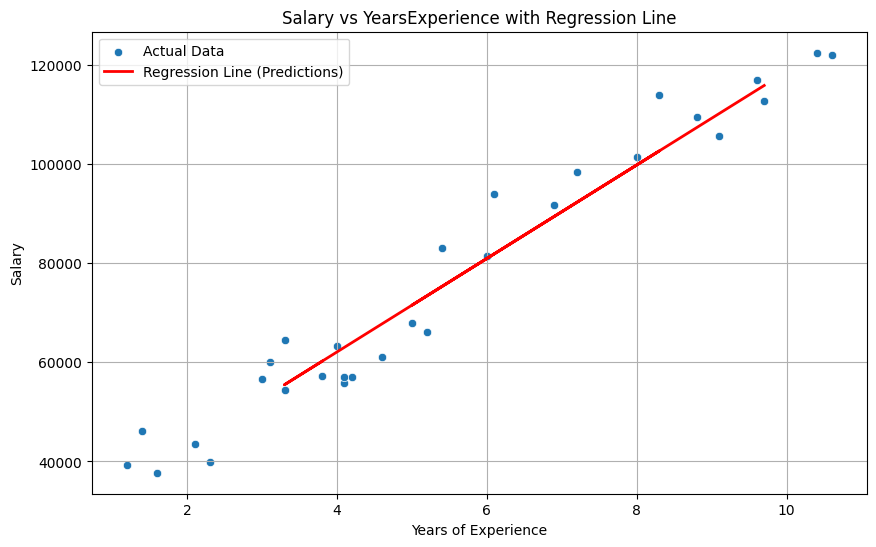

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='YearsExperience', y='Salary', data=data, label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line (Predictions)')
plt.title('Salary vs YearsExperience with Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()